# Transport-matrix inversion benchmark

This notebook:

1. Loads your air-quality dataset.
2. Builds the Gaussian-plume transport matrix for many time snapshots.
3. Runs multiple inversion methods.
4. Compares reconstruction quality using several metrics.
5. Produces summary tables and charts.

Place this notebook in the same folder as `transport_matrix.py`.


In [18]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import nnls
from scipy.stats import pearsonr
from scipy.linalg import svd

from sklearn.linear_model import Ridge

plt.rcParams["figure.figsize"] = (11, 5)

# Make sure the local helper module is importable.
NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from transport_matrix import build_transport_matrix, stability_class


## 1) Configure your dataset

Edit the file path and column names below to match your dataset.
The notebook assumes one row per station per timestamp.


In [22]:
# ---- EDIT THESE ----
ROOT_DIR = Path().resolve().parents[2]
DATA_DIR = ROOT_DIR / "backend" / "data"
MASTER_DATASET_FILE = DATA_DIR / "artifacts" / "final_master_dataset.csv"
STATIONS_FILE = DATA_DIR / "raw" / "stations.csv"

TIME_COL = "time"
STATION_COL = "station_name"

POLLUTANT = "pm25"                   # change to your pollutant column
WS_COL = "wind_speed"
WD_COL = "wind_direction"
SR_COL = "solar_radiation"
LAT_COL = "latitude"
LON_COL = "longitude"

# If you already know the station order, set it here.
# Otherwise the notebook will infer it from the first valid time snapshot.
STATION_NAMES = None  # e.g. ["S1", "S2", ..., "S14"]

MIN_VALID_STATIONS = 12     # threshold used to select snapshots
N_SNAPSHOTS_MAX = 50        # cap for faster runs; set None for all
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 2) Load data and basic cleanup


In [23]:
def load_dataset(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(
            f"{path} not found. Put your dataset here or update DATA_PATH."
        )

    if path.suffix.lower() in {".parquet", ".pq"}:
        df = pd.read_parquet(path)
    elif path.suffix.lower() in {".csv", ".txt"}:
        df = pd.read_csv(path)
    else:
        raise ValueError("Supported file types: .csv, .txt, .parquet, .pq")

    if TIME_COL not in df.columns:
        raise KeyError(f"Missing required time column: {TIME_COL}")
    df[TIME_COL] = pd.to_datetime(df[TIME_COL])
    return df


df_full = load_dataset(MASTER_DATASET_FILE)
display(df_full.head())
print(df_full.shape)
print(df_full.columns.tolist())


,time,pm25,pm10,no,no2,nox,nh3,so2,co,o3,...,wind_direction,rainfall,total_rainfall,solar_radiation,pressure,station_name,site,org,latitude,longitude
0,2025-01-01 00:00:00,36.0,90.0,3.1,11.8,9.8,5.0,4.50,500.0,33.3,...,114.0,0.0,0.0,0.0,727.0,BapujiNagar,1553,KSPCB,12.951913,77.539784
1,2025-01-01 00:15:00,36.0,90.0,3.2,12.4,10.2,5.3,4.60,480.0,35.5,...,112.0,0.0,0.0,0.0,727.0,BapujiNagar,1553,KSPCB,12.951913,77.539784
2,2025-01-01 00:30:00,36.0,90.0,3.2,11.3,9.6,5.0,4.70,560.0,33.6,...,117.0,0.0,0.0,0.0,727.0,BapujiNagar,1553,KSPCB,12.951913,77.539784
3,2025-01-01 00:45:00,47.0,118.0,2.7,12.3,9.7,5.2,4.85,640.0,34.2,...,112.0,0.0,0.0,0.0,726.0,BapujiNagar,1553,KSPCB,12.951913,77.539784
4,2025-01-01 01:00:00,47.0,118.0,2.8,11.2,9.3,5.8,5.00,780.0,33.3,...,118.0,0.0,0.0,0.0,726.0,BapujiNagar,1553,KSPCB,12.951913,77.539784


(467232, 25)
['time', 'pm25', 'pm10', 'no', 'no2', 'nox', 'nh3', 'so2', 'co', 'o3', 'benzene', 'toluene', 'average_temperature', 'relative_humidity', 'wind_speed', 'wind_direction', 'rainfall', 'total_rainfall', 'solar_radiation', 'pressure', 'station_name', 'site', 'org', 'latitude', 'longitude']


In [24]:
# Validate and standardize only; do NOT drop station rows here.
required_cols = [
    TIME_COL, STATION_COL, POLLUTANT, WS_COL, WD_COL, SR_COL, LAT_COL, LON_COL
]
missing = [c for c in required_cols if c not in df_full.columns]
if missing:
    raise KeyError(f"Dataset is missing required columns: {missing}")

df_full = df_full.copy()
df_full[TIME_COL] = pd.to_datetime(df_full[TIME_COL])
df_full = df_full.sort_values([TIME_COL, STATION_COL]).reset_index(drop=True)

# Keep a fixed station order for all snapshots.
if STATION_NAMES is None:
    STATION_NAMES = (
        df_full[STATION_COL]
        .dropna()
        .astype(str)
        .drop_duplicates()
        .tolist()
    )

N = len(STATION_NAMES)
print(f"Stations: {N}")
print(STATION_NAMES)

Stations: 14
['BapujiNagar', 'BtmLayout', 'CityRailwayStation', 'Hebbal', 'HombegowdaNagar', 'Jayanagar5thBlock', 'Jigani', 'KasturiNagar', 'Peenya', 'RvceMailasandra', 'SaneguravaHalli', 'ShivapuraPeenya', 'SilkBoard', 'BwssbKadabesanahalli']


## 3) Helper functions

These functions:
- build a per-snapshot transport matrix,
- solve the inverse problem with several methods,
- evaluate each reconstruction against the observed concentrations.


In [25]:
def extract_snapshot(df_full, t0):
    # 1. We Transpose the table at station_name (so station_names becomes columns)
    before_rows = len(df_full)
    filtered_df = df_full.dropna(subset=[POLLUTANT, "wind_speed", "wind_direction"])
    after_rows = len(filtered_df)
    dropped_rows = before_rows - after_rows
    print(f"1. Dropping rows which dont have [{POLLUTANT},wind_speed or wind_direction]")
    print(f"{before_rows:,} - {after_rows:,}: {dropped_rows:,}")

    # 2. First Pivot the table ar station_name
    pivot_check = filtered_df.pivot_table(
        index="time", columns="station_name", values=POLLUTANT, aggfunc="first"
    )
    print(
        f"Pivoted table <Transposes the df by considering station_name as columns and {POLLUTANT} as row values > :"
    )
    display(pivot_check.head(3))

    # 3. Keep times where at least 12 stations have data
    print("2. Keep times with a minimum threshold of valid stations")
    before_rows = len(pivot_check)
    full_rows = pivot_check.dropna(axis=0, thresh=12)
    after_rows = len(full_rows)
    pivot_dropped_rows = before_rows - after_rows
    print(f"Timestamps surviving threshold: {after_rows:,}")
    print(f"{before_rows:,} - {after_rows:,}: {pivot_dropped_rows:,}")
    display(full_rows.head(3))

    # 4. Select the earliest valid time
    if len(full_rows) > 0:
        t0 = full_rows.index[0]
    else:
        t0 = filtered_df["time"].min()
    print(f"Selected snapshot time: {t0}")

    # 5. Select the C, WS, WD and SR for this particular timeperiod
    snap = filtered_df[filtered_df["time"] == t0].set_index("station_name")
    display(snap)
    print(snap.shape)

    C_obs_list = []
    WS_list = []
    WD_list = []
    SR_list = []

    for s in STATION_NAMES:
        if s in snap.index:
            C_obs_list.append(snap.loc[s, POLLUTANT])
            WS_list.append(snap.loc[s, "wind_speed"])
            WD_list.append(snap.loc[s, "wind_direction"])
            SR_list.append(snap.loc[s, "solar_radiation"])
        else:
            C_obs_list.append(np.nan)
            WS_list.append(np.nan)
            WD_list.append(np.nan)
            SR_list.append(np.nan)

    C_obs = np.array(C_obs_list, dtype=float)
    WS = np.array(WS_list, dtype=float)
    WD = np.array(WD_list, dtype=float)
    SR = np.array(SR_list, dtype=float)
    hour = t0.hour

    nan_counts = {
        "Pollutant (C_obs)": np.isnan(C_obs).sum(),
        "Wind Speed (WS)": np.isnan(WS).sum(),
        "Wind Direction (WD)": np.isnan(WD).sum(),
        "Solar Radiation (SR)": np.isnan(SR).sum(),
    }

    print("NaN Counts Before Imputation ")
    for var_name, count in nan_counts.items():
        print(f"{var_name:<20}: {count} NaN(s) detected")

    C_obs = np.where(np.isnan(C_obs), np.nanmedian(C_obs), C_obs)
    WS = np.where(np.isnan(WS), np.nanmedian(WS), WS)
    WD = np.where(np.isnan(WD), np.nanmedian(WD), WD)
    SR = np.where(np.isnan(SR), np.nanmedian(SR), SR)

    print(f"{'Stations':<20}: {N}")
    print(f"{'Pollutant':<20}: {POLLUTANT}")
    print(f"{'Wind speed range':<20}: {WS.min():.2f} - {WS.max():.2f} m/s")
    print(f"{'Wind dir range':<20}: {WD.min():.1f}° - {WD.max():.1f}°")
    display(filtered_df.isnull().sum())

    return filtered_df, pivot_check, full_rows, t0, snap, C_obs, WS, WD, SR, hour

In [26]:
def select_snapshot_times(df: pd.DataFrame, min_valid_stations: int = 12) -> list:
    """
    Return timestamps where at least `min_valid_stations` stations have
    pollutant measurements.
    """
    counts = (
        df.groupby(TIME_COL)[POLLUTANT]
        .count()
        .sort_index()
    )
    valid_times = counts[counts >= min_valid_stations].index.to_list()
    return valid_times


def get_snapshot_frame(df: pd.DataFrame, t0) -> pd.DataFrame:
    snap = df[df[TIME_COL] == t0].copy()
    snap = snap.drop_duplicates(subset=[STATION_COL], keep="first")
    snap = snap.set_index(STATION_COL)
    return snap


def build_station_vectors(
    snap: pd.DataFrame,
    station_names: list,
    pollutant_col: str = POLLUTANT,
):
    """
    Return aligned arrays in station order.
    Missing stations are filled with NaN.
    """
    C_obs, WS, WD, SR, lats, lons = [], [], [], [], [], []

    for s in station_names:
        if s in snap.index:
            row = snap.loc[s]
            C_obs.append(float(row[pollutant_col]))
            WS.append(float(row[WS_COL]))
            WD.append(float(row[WD_COL]))
            SR.append(float(row[SR_COL]))
            lats.append(float(row[LAT_COL]))
            lons.append(float(row[LON_COL]))
        else:
            C_obs.append(np.nan)
            WS.append(np.nan)
            WD.append(np.nan)
            SR.append(np.nan)
            lats.append(np.nan)
            lons.append(np.nan)

    return (
        np.asarray(C_obs, dtype=float),
        np.asarray(WS, dtype=float),
        np.asarray(WD, dtype=float),
        np.asarray(SR, dtype=float),
        np.asarray(lats, dtype=float),
        np.asarray(lons, dtype=float),
    )


def impute_nan_with_median(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    if np.all(np.isnan(x)):
        return np.zeros_like(x)
    med = np.nanmedian(x)
    return np.where(np.isnan(x), med, x)


def normalized_solve_setup(T: np.ndarray, C: np.ndarray):
    """
    Normalize T and C for numerical stability.
    Returns T_norm, C_norm, T_scale, C_scale.
    """
    T_scale = np.nanmax(np.abs(T))
    C_scale = np.nanmax(np.abs(C))

    if not np.isfinite(T_scale) or T_scale == 0:
        T_scale = 1.0
    if not np.isfinite(C_scale) or C_scale == 0:
        C_scale = 1.0

    T_norm = T / T_scale
    C_norm = C / C_scale
    return T_norm, C_norm, T_scale, C_scale


def rescale_q(Q_norm: np.ndarray, T_scale: float, C_scale: float) -> np.ndarray:
    """
    If C_norm = T_norm @ Q_norm, then Q_raw = (C_scale / T_scale) * Q_norm.
    """
    return Q_norm * (C_scale / T_scale)


def solve_lstsq(T: np.ndarray, C: np.ndarray) -> np.ndarray:
    Q, *_ = np.linalg.lstsq(T, C, rcond=None)
    return Q


def solve_nnls(T: np.ndarray, C: np.ndarray) -> np.ndarray:
    Q, _ = nnls(T, C)
    return Q


def solve_ridge(T: np.ndarray, C: np.ndarray, alpha: float = 1.0) -> np.ndarray:
    model = Ridge(alpha=alpha, fit_intercept=False, positive=True)
    model.fit(T, C)
    return model.coef_


def solve_truncsvd(T: np.ndarray, C: np.ndarray, energy: float = 0.90) -> np.ndarray:
    """
    Truncated SVD pseudo-inverse.
    Keeps the smallest number of singular values needed to explain `energy`.
    """
    U, s, Vt = svd(T, full_matrices=False)
    if len(s) == 0:
        return np.zeros(T.shape[1])

    explained = np.cumsum(s**2) / np.sum(s**2)
    k = int(np.searchsorted(explained, energy) + 1)
    k = max(1, min(k, len(s)))

    Uk = U[:, :k]
    sk = s[:k]
    Vtk = Vt[:k, :]

    Q = Vtk.T @ ((Uk.T @ C) / sk)
    return Q


def predict_concentration(T: np.ndarray, Q: np.ndarray) -> np.ndarray:
    return T @ Q


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    eps = 1e-12
    resid = y_true - y_pred
    rmse = float(np.sqrt(np.mean(resid**2)))
    mae = float(np.mean(np.abs(resid)))
    denom = np.sum((y_true - y_true.mean())**2)
    r2 = float(1 - np.sum(resid**2) / denom) if denom > eps else np.nan
    mape = float(np.mean(np.abs(resid) / np.maximum(np.abs(y_true), eps)) * 100)
    nrmse = float(rmse / (np.max(y_true) - np.min(y_true) + eps))
    residual_norm = float(np.linalg.norm(resid))
    corr = float(pearsonr(y_true, y_pred)[0]) if len(y_true) >= 2 and np.std(y_true) > 0 and np.std(y_pred) > 0 else np.nan

    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "mape_pct": mape,
        "nrmse": nrmse,
        "residual_norm": residual_norm,
        "pearson_r": corr,
    }


def q_metrics(Q: np.ndarray, zero_tol: float = 1e-8) -> dict:
    Q = np.asarray(Q, dtype=float)
    return {
        "q_sum": float(np.nansum(Q)),
        "q_mean": float(np.nanmean(Q)),
        "q_max": float(np.nanmax(Q)),
        "q_sparsity_pct": float(100 * np.mean(np.abs(Q) <= zero_tol)),
    }


def matrix_diagnostics(T: np.ndarray) -> dict:
    s = svd(T, compute_uv=False)
    if len(s) == 0:
        cond = np.nan
        rank = 0
        eff_rank = np.nan
    else:
        cond = float(s[0] / s[-1]) if s[-1] > 0 else np.inf
        rank = int(np.sum(s > (np.max(s) * max(T.shape) * np.finfo(float).eps)))
        p = s / np.sum(s)
        eff_rank = float(np.exp(-np.sum(p * np.log(p + 1e-12))))
    sparsity = float(100 * np.mean(np.isclose(T, 0.0)))
    return {
        "rank": rank,
        "condition_number": cond,
        "effective_rank": eff_rank,
        "T_sparsity_pct": sparsity,
    }


METHODS = {
    "lstsq": solve_lstsq,
    "nnls": solve_nnls,
    "ridge": lambda T, C: solve_ridge(T, C, alpha=1.0),
    "truncsvd": lambda T, C: solve_truncsvd(T, C, energy=0.90),
}


## 4) Run the benchmark over multiple snapshots

For each timestamp:
- build the transport matrix,
- solve for emissions using every method,
- reconstruct concentrations,
- store metrics and diagnostics.


In [51]:
def circular_interpolate(series: pd.Series) -> pd.Series:
    """
    Interpolate wind direction correctly across the 0–360° boundary.
    Naive linear interpolation on angles gives wrong results near 0/360.
    For example, midpoint between 350° and 10° should be 0°, not 180°.
    Fix: convert to sin/cos (cartesian), interpolate those, convert back.
    """
    rad = np.radians(series)
    sin_i = np.sin(rad).interpolate(method="linear", limit_direction="both")
    cos_i = np.cos(rad).interpolate(method="linear", limit_direction="both")
    return pd.Series(
        np.degrees(np.arctan2(sin_i, cos_i)) % 360,
        index=series.index,
    )

In [52]:
from tqdm import tqdm

imputation_log = []
all_imputed = []
master_df = df_full

STATION_NAMES = master_df["station_name"].unique()

CIRCULAR_COLS = ["wind_direction"]
FFILL_COLS = ["rainfall", "total_rainfall"]

MAX_LINEAR_STEPS = 24   # 6 hours at 15-min data
MAX_ROLLING_STEPS = 4   # 1 hour at 15-min data

for station in tqdm(STATION_NAMES, desc="Imputing stations"):
    print("Now working on station:", station)

    # Isolate one station and make a regular 15-min grid
    df = master_df[master_df["station_name"] == station].copy()
    df = df.set_index("time").sort_index()
    df = df.asfreq("15min")

    # Forward-fill metadata columns
    meta_cols = df.select_dtypes(exclude=np.number).columns.tolist()
    df[meta_cols] = df[meta_cols].ffill()

    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

    # STEP 1 — cumulative rainfall columns
    for col in FFILL_COLS:
        if col in df.columns:
            before = df[col].isna().sum()
            df[col] = df[col].ffill().fillna(0)
            filled = before - df[col].isna().sum()
            if filled:
                imputation_log.append(
                    dict(station=station, col=col, method="ffill", n_filled=filled)
                )

    # STEP 2 — circular interpolation for wind direction
    for col in CIRCULAR_COLS:
        if col in df.columns and df[col].isna().sum() > 0:
            before = df[col].isna().sum()
            df[col] = circular_interpolate(df[col])
            filled = before - df[col].isna().sum()
            if filled:
                imputation_log.append(
                    dict(
                        station=station,
                        col=col,
                        method="circular_interp",
                        n_filled=filled,
                    )
                )

    # STEP 3 — linear interpolation for the remaining numeric columns
    remaining_cols = [c for c in numeric_cols if c not in FFILL_COLS + CIRCULAR_COLS]
    for col in remaining_cols:
        if df[col].isna().sum() == 0:
            continue
        before = df[col].isna().sum()
        df[col] = df[col].interpolate(method="linear", limit=MAX_LINEAR_STEPS)
        filled = before - df[col].isna().sum()
        if filled:
            imputation_log.append(
                dict(station=station, col=col, method="linear_interp", n_filled=filled)
            )

    # STEP 4 — rolling median
    for col in remaining_cols:
        if df[col].isna().sum() == 0:
            continue
        rolling_med = df[col].rolling(window=MAX_ROLLING_STEPS, min_periods=1).median()
        missing_mask = df[col].isna()
        df.loc[missing_mask, col] = rolling_med[missing_mask]
        filled = missing_mask.sum() - df[col].isna().sum()
        if filled:
            imputation_log.append(
                dict(
                    station=station,
                    col=col,
                    method="rolling_1h_median",
                    n_filled=filled,
                )
            )

    # STEP 5 — same time previous day
    for col in remaining_cols:
        if df[col].isna().sum() == 0:
            continue
        n_filled = 0
        for idx in df[df[col].isna()].index:
            prev = idx - pd.Timedelta(days=1)
            if prev in df.index and pd.notna(df.loc[prev, col]):
                df.loc[idx, col] = df.loc[prev, col]
                n_filled += 1
        if n_filled:
            imputation_log.append(
                dict(station=station, col=col, method="prev_day", n_filled=n_filled)
            )

    # STEP 6 — same time previous week
    for col in remaining_cols:
        if df[col].isna().sum() == 0:
            continue
        n_filled = 0
        for idx in df[df[col].isna()].index:
            prev = idx - pd.Timedelta(days=7)
            if prev in df.index and pd.notna(df.loc[prev, col]):
                df.loc[idx, col] = df.loc[prev, col]
                n_filled += 1
        if n_filled:
            imputation_log.append(
                dict(station=station, col=col, method="prev_week", n_filled=n_filled)
            )

    # STEP 7 — month x hour median
    for col in remaining_cols:
        if df[col].isna().sum() == 0:
            continue
        medians = df.groupby([df.index.month, df.index.hour])[col].median()
        n_filled = 0
        for idx in df[df[col].isna()].index:
            key = (idx.month, idx.hour)
            if key in medians.index and pd.notna(medians[key]):
                df.loc[idx, col] = medians[key]
                n_filled += 1
        if n_filled:
            imputation_log.append(
                dict(
                    station=station,
                    col=col,
                    method="month_hour_median",
                    n_filled=n_filled,
                )
            )

    # STEP 8 — column median fallback
    for col in remaining_cols:
        n = df[col].isna().sum()
        if n == 0:
            continue
        median_val = df[col].median()
        if pd.isna(median_val):
            median_val = 0.0
        df[col] = df[col].fillna(median_val)
        imputation_log.append(
            dict(station=station, col=col, method="col_median", n_filled=n)
        )

    # Optional warning for still-sparse columns
    still_missing = df[numeric_cols].isna().mean()
    sparse = still_missing[still_missing > 0.0]
    if not sparse.empty:
        print(f"SPARSE columns in {station} (>50% missing even after imputation):")
        print(sparse.round(2).to_string())

    df_out = df.reset_index()
    all_imputed.append(df_out)

master_df_imputed = pd.concat(all_imputed, ignore_index=True)
master_df_imputed = master_df_imputed.sort_values(["time", "station_name"]).reset_index(drop=True)

print("Imputation complete.")
print(master_df_imputed.shape)

Imputing stations:   7%|▋         | 1/14 [00:00<00:01,  9.27it/s]

Now working on station: BapujiNagar
Now working on station: BtmLayout
Now working on station: CityRailwayStation


Imputing stations:  29%|██▊       | 4/14 [00:00<00:01,  9.84it/s]

SPARSE columns in CityRailwayStation (>50% missing even after imputation):
wind_direction    1.0
Now working on station: Hebbal
Now working on station: HombegowdaNagar


Imputing stations:  43%|████▎     | 6/14 [00:00<00:00,  8.96it/s]

...

Now working on station: Peenya
SPARSE columns in Peenya (>50% missing even after imputation):
wind_direction    1.0
Now working on station: RvceMailasandra
Now working on station: SaneguravaHalli


Imputing stations:  93%|█████████▎| 13/14 [00:01<00:00, 10.70it/s]

SPARSE columns in SaneguravaHalli (>50% missing even after imputation):
wind_direction    1.0
Now working on station: ShivapuraPeenya
Now working on station: SilkBoard
Now working on station: BwssbKadabesanahalli


Imputing stations: 100%|██████████| 14/14 [00:01<00:00, 10.14it/s]


Imputation complete.
(467232, 25)


In [54]:
df_full = master_df_imputed.copy()

snapshot_times = select_snapshot_times(df_full, min_valid_stations=MIN_VALID_STATIONS)

if N_SNAPSHOTS_MAX is not None:
    snapshot_times = snapshot_times[:N_SNAPSHOTS_MAX]

print(f"Snapshots selected: {len(snapshot_times)}")
# print("First few:", snapshot_times[:5])

all_results = []
all_q = {}
all_predictions = {}
all_diagnostics = {}

for t0 in snapshot_times:
    filtered_df, pivot_check, full_rows, t0, snap, C_obs, WS, WD, SR, hour = extract_snapshot(
        df_full, t0=t0
    )

    # Get lats/lons from the same snapshot
    _, _, _, _, lats, lons = build_station_vectors(snap, STATION_NAMES, POLLUTANT)

    is_daytime = 6 <= pd.Timestamp(t0).hour <= 18
    stability = [stability_class(ws, sr, is_daytime) for ws, sr in zip(WS, SR)]

    T = build_transport_matrix(
        lats=lats,
        lons=lons,
        wind_speeds=WS,
        wind_directions=WD,
        stability_classes=stability,
    )

    diag = matrix_diagnostics(T)
    T_norm, C_norm, T_scale, C_scale = normalized_solve_setup(T, C_obs)

    all_diagnostics[t0] = {
        **diag,
        "T_scale": float(T_scale),
        "C_scale": float(C_scale),
        "n_valid_obs": int(np.sum(np.isfinite(C_obs))),
    }

    for method_name, solver in METHODS.items():
        try:
            Q_norm = solver(T_norm, C_norm)
            Q = rescale_q(Q_norm, T_scale, C_scale)
            C_pred = predict_concentration(T, Q)

            m = regression_metrics(C_obs, C_pred)
            qm = q_metrics(Q)

            row = {
                "time": t0,
                "method": method_name,
                **diag,
                **m,
                **qm,
            }
            all_results.append(row)
            all_q[(t0, method_name)] = Q
            all_predictions[(t0, method_name)] = C_pred

        except Exception as e:
            all_results.append({
                "time": t0,
                "method": method_name,
                "error": str(e),
                **diag,
            })

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(["method", "time"]).reset_index(drop=True)

Snapshots selected: 50
1. Dropping rows which dont have [pm25,wind_speed or wind_direction]
467,232 - 362,112: 105,120
Pivoted table <Transposes the df by considering station_name as columns and pm25 as row values > :


station_name,BapujiNagar,BtmLayout,BwssbKadabesanahalli,Hebbal,HombegowdaNagar,Jayanagar5thBlock,Jigani,KasturiNagar,RvceMailasandra,ShivapuraPeenya,SilkBoard
time,,,,,,,,,,,
2025-01-01 00:00:00,36.0,44.86,NaN,62.0,61.0,65.0,71.16,32.99,1.05,29.0,57.0
2025-01-01 00:15:00,36.0,47.50,NaN,62.0,61.0,65.0,71.16,32.99,1.05,29.0,57.0
2025-01-01 00:30:00,36.0,47.77,NaN,62.0,61.0,65.0,71.16,32.99,0.99,29.0,57.0


2. Keep times with a minimum threshold of valid stations
Timestamps surviving threshold: 0
35,040 - 0: 35,040


station_name,BapujiNagar,BtmLayout,BwssbKadabesanahalli,Hebbal,HombegowdaNagar,Jayanagar5thBlock,Jigani,KasturiNagar,RvceMailasandra,ShivapuraPeenya,SilkBoard
time,,,,,,,,,,,


Selected snapshot time: 2025-01-01 00:00:00


...

station_name,BapujiNagar,BtmLayout,BwssbKadabesanahalli,Hebbal,HombegowdaNagar,Jayanagar5thBlock,Jigani,KasturiNagar,RvceMailasandra,ShivapuraPeenya,SilkBoard
time,,,,,,,,,,,


Selected snapshot time: 2025-01-01 00:00:00


,time,pm25,pm10,no,no2,nox,nh3,so2,co,o3,...,wind_speed,wind_direction,rainfall,total_rainfall,solar_radiation,pressure,site,org,latitude,longitude
station_name,,,,,,,,,,,,,,,,,,,,,
BapujiNagar,2025-01-01,36.00,90.00,3.10,11.800,9.800,5.00,4.500,500.0,33.300,...,0.00,114.00,0.0,0.0,0.00,727.00,1553,KSPCB,12.951913,77.539784
BtmLayout,2025-01-01,44.86,85.11,8.64,38.290,46.930,14.51,10.320,550.0,21.970,...,0.99,224.64,0.0,0.0,31.95,936.90,162,CPCB,12.913522,77.595080
Hebbal,2025-01-01,62.00,98.00,0.00,48.300,0.000,3.30,12.600,240.0,5.490,...,0.50,97.00,0.0,0.0,0.00,0.00,1554,KSPCB,13.029152,77.585901
HombegowdaNagar,2025-01-01,61.00,101.00,0.20,9.900,5.500,6.00,15.700,510.0,35.570,...,0.00,197.00,0.0,0.0,0.00,717.00,1555,KSPCB,12.938539,77.590100
Jayanagar5thBlock,2025-01-01,65.00,95.00,1.60,3.700,4.500,2.00,6.500,270.0,15.480,...,0.00,156.00,0.0,0.0,0.00,718.00,1556,KSPCB,12.920984,77.584908
Jigani,2025-01-01,71.16,108.45,4.27,31.470,35.680,26.84,11.620,630.0,23.360,...,5.50,114.61,0.0,0.0,6.43,996.64,5729,KSPCB,12.781628,77.629914
KasturiNagar,2025-01-01,32.99,42.92,6.70,23.860,31.760,24.93,11.970,460.0,29.890,...,1.57,42.49,0.0,0.0,10.48,914.49,5681,KSPCB,13.003872,77.664217
RvceMailasandra,2025-01-01,1.05,69.31,5.81,31.150,36.630,16.02,4.560,700.0,22.160,...,2.31,254.72,0.0,0.0,0.00,0.00,5678,KSPCB,12.921418,77.502466
ShivapuraPeenya,2025-01-01,29.00,121.58,6.73,12.445,18.495,10.60,5.835,1040.0,25.645,...,0.46,78.17,0.0,0.0,0.00,939.49,5686,KSPCB,13.024634,77.508011


(10, 24)
NaN Counts Before Imputation 
Pollutant (C_obs)   : 4 NaN(s) detected
Wind Speed (WS)     : 4 NaN(s) detected
Wind Direction (WD) : 4 NaN(s) detected
Solar Radiation (SR): 4 NaN(s) detected
Stations            : 14
Pollutant           : pm25
Wind speed range    : 0.00 - 5.50 m/s
Wind dir range      : 42.5° - 254.7°


time                   0
pm25                   0
pm10                   0
no                     0
no2                    0
nox                    0
nh3                    0
so2                    0
co                     0
o3                     0
benzene                0
toluene                0
average_temperature    0
relative_humidity      0
wind_speed             0
wind_direction         0
rainfall               0
total_rainfall         0
solar_radiation        0
pressure               0
station_name           0
site                   0
org                    0
latitude               0
longitude              0
dtype: int64

## 5) Summary tables


In [55]:
summary = (
    results_df
    .groupby("method", as_index=False)
    .agg(
        rmse_mean=("rmse", "mean"),
        rmse_std=("rmse", "std"),
        mae_mean=("mae", "mean"),
        r2_mean=("r2", "mean"),
        mape_mean=("mape_pct", "mean"),
        residual_norm_mean=("residual_norm", "mean"),
        pearson_r_mean=("pearson_r", "mean"),
        q_sparsity_mean=("q_sparsity_pct", "mean"),
    )
    .sort_values("rmse_mean")
)

display(summary)

diag_summary = pd.DataFrame([
    {"time": t, **vals} for t, vals in all_diagnostics.items()
]).sort_values("time")
display(diag_summary.head())


,method,rmse_mean,rmse_std,mae_mean,r2_mean,mape_mean,residual_norm_mean,pearson_r_mean,q_sparsity_mean
0,lstsq,36.102019,0.0,26.830714,-3.298099,64.285714,135.081386,0.544073,64.285714
1,nnls,36.102019,0.0,26.830714,-3.298099,64.285714,135.081386,0.544073,64.285714
3,truncsvd,47.428192,0.0,42.770000,-6.417995,92.857143,177.460045,0.280111,92.857143
2,ridge,48.064207,0.0,44.960264,-6.618280,96.198459,179.839794,0.289536,78.571429


,time,rank,condition_number,effective_rank,T_sparsity_pct,T_scale,C_scale,n_valid_obs
0,2025-01-01,5,inf,1.537426,97.44898,277.466538,71.16,14


## 6) Charts

These plots compare the methods over time and across snapshots.


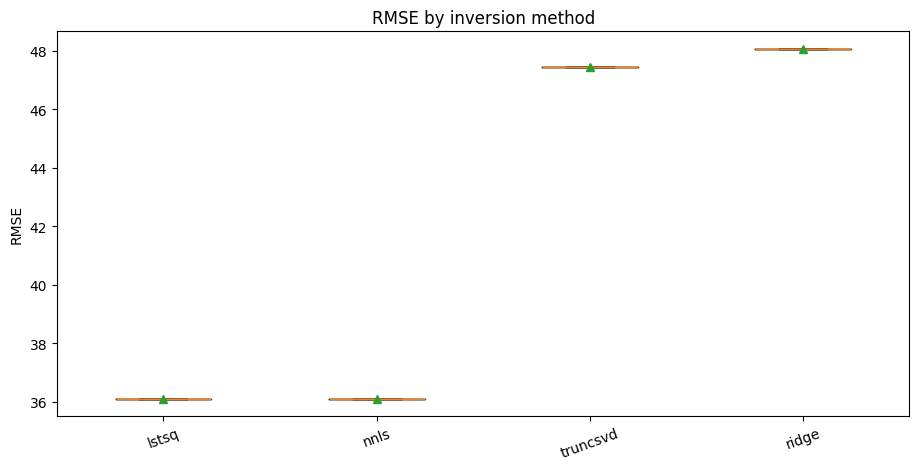

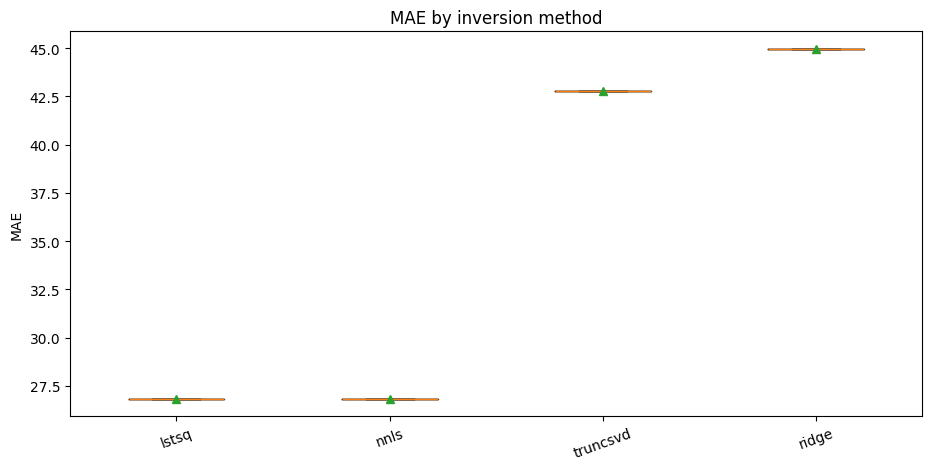

In [56]:
methods_order = summary["method"].tolist()

fig, ax = plt.subplots()
box_data = [results_df.loc[results_df["method"] == m, "rmse"].dropna() for m in methods_order]
ax.boxplot(box_data, tick_labels=methods_order, showmeans=True)
ax.set_title("RMSE by inversion method")
ax.set_ylabel("RMSE")
plt.xticks(rotation=20)
plt.show()

fig, ax = plt.subplots()
box_data = [results_df.loc[results_df["method"] == m, "mae"].dropna() for m in methods_order]
ax.boxplot(box_data, tick_labels=methods_order, showmeans=True)
ax.set_title("MAE by inversion method")
ax.set_ylabel("MAE")
plt.xticks(rotation=20)
plt.show()


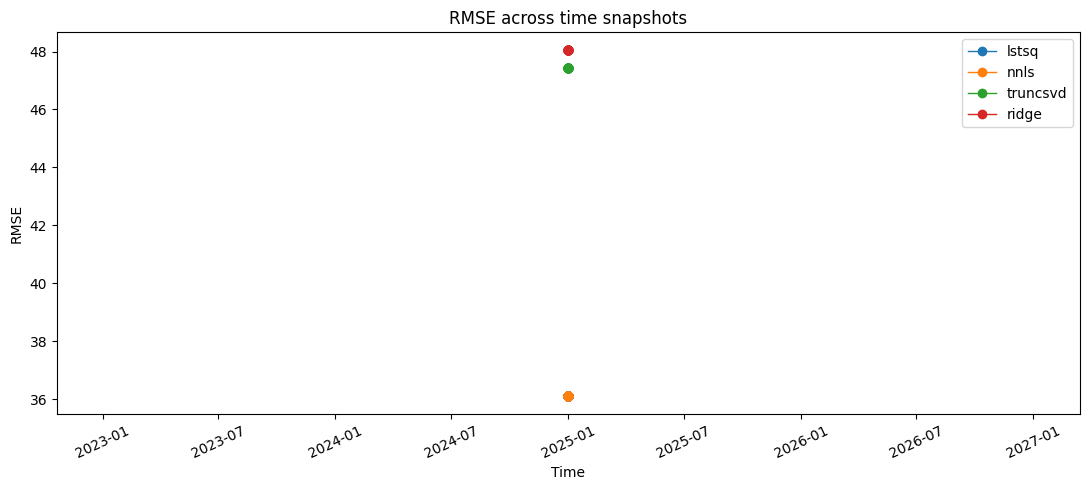

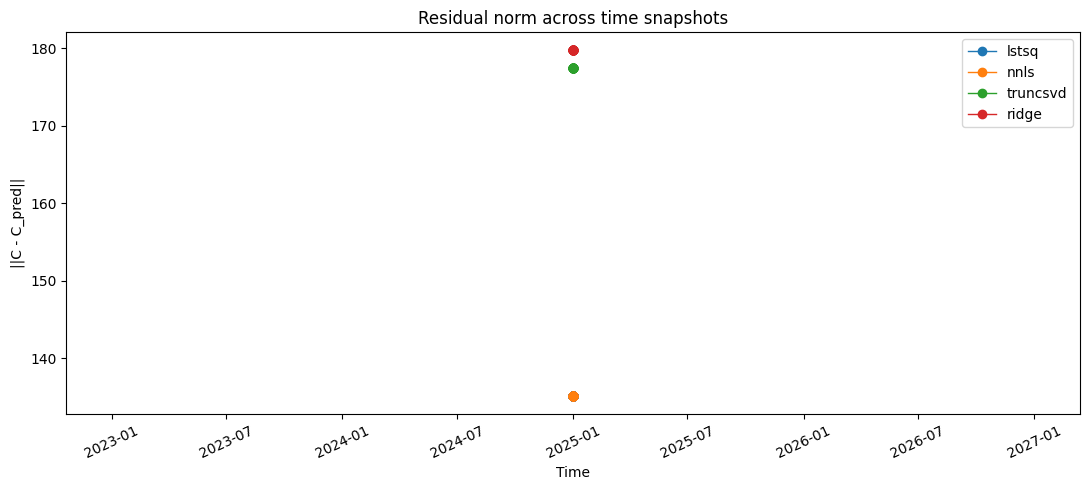

In [57]:
fig, ax = plt.subplots()
for m in methods_order:
    tmp = results_df[results_df["method"] == m].sort_values("time")
    ax.plot(tmp["time"], tmp["rmse"], marker="o", linewidth=1, label=m)
ax.set_title("RMSE across time snapshots")
ax.set_xlabel("Time")
ax.set_ylabel("RMSE")
ax.legend()
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
for m in methods_order:
    tmp = results_df[results_df["method"] == m].sort_values("time")
    ax.plot(tmp["time"], tmp["residual_norm"], marker="o", linewidth=1, label=m)
ax.set_title("Residual norm across time snapshots")
ax.set_xlabel("Time")
ax.set_ylabel("||C - C_pred||")
ax.legend()
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


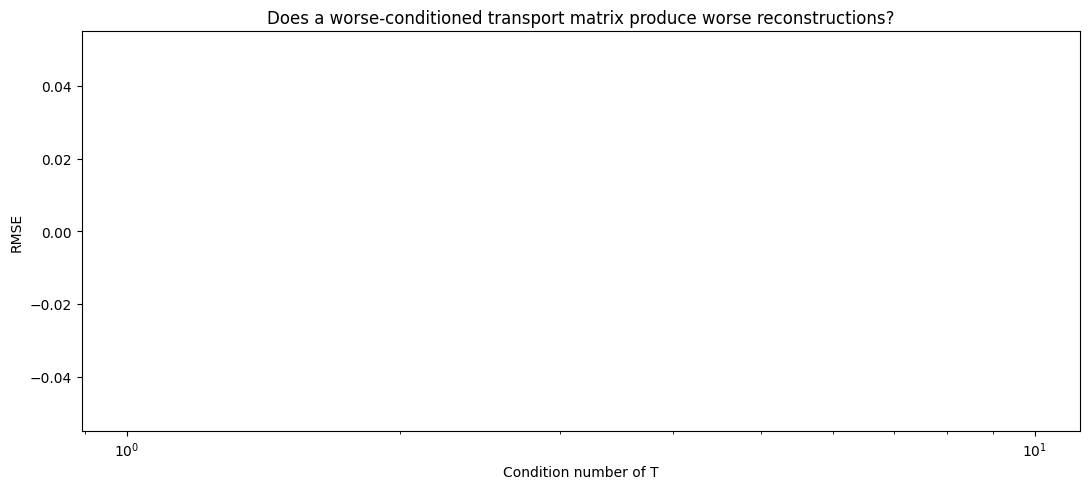

In [58]:
fig, ax = plt.subplots()
ax.scatter(results_df["condition_number"], results_df["rmse"], alpha=0.7)
ax.set_xscale("log")
ax.set_xlabel("Condition number of T")
ax.set_ylabel("RMSE")
ax.set_title("Does a worse-conditioned transport matrix produce worse reconstructions?")
plt.tight_layout()
plt.show()


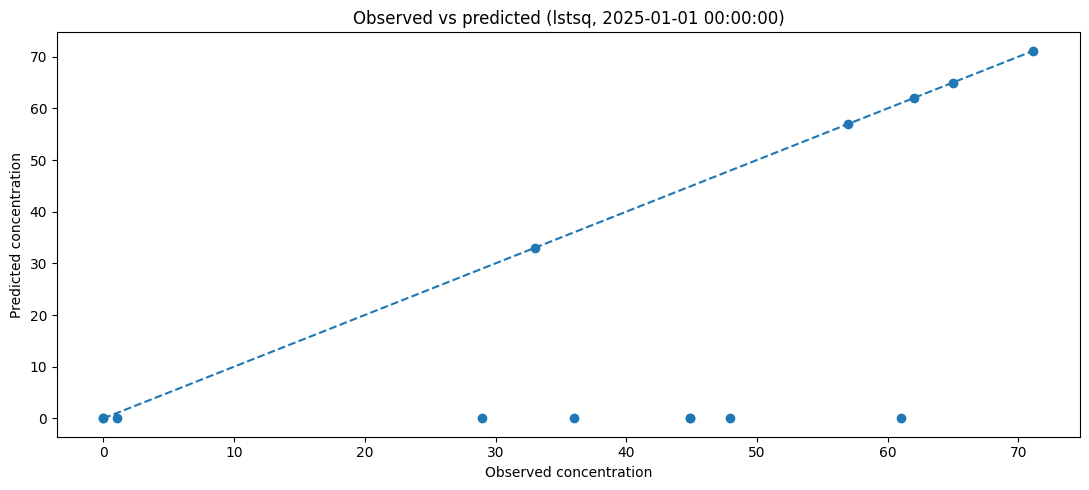

In [59]:
# Pick one snapshot to inspect in detail
example_time = snapshot_times[0]
example_method = methods_order[0]

C_ex = all_predictions[(example_time, example_method)]
C_obs_ex = (
    get_snapshot_frame(df_full, example_time)
    .reindex(STATION_NAMES)[POLLUTANT]
    .astype(float)
    .to_numpy()
)
C_obs_ex = impute_nan_with_median(C_obs_ex)

fig, ax = plt.subplots()
ax.scatter(C_obs_ex, C_ex)
mn = min(C_obs_ex.min(), C_ex.min())
mx = max(C_obs_ex.max(), C_ex.max())
ax.plot([mn, mx], [mn, mx], linestyle="--")
ax.set_xlabel("Observed concentration")
ax.set_ylabel("Predicted concentration")
ax.set_title(f"Observed vs predicted ({example_method}, {example_time})")
plt.tight_layout()
plt.show()


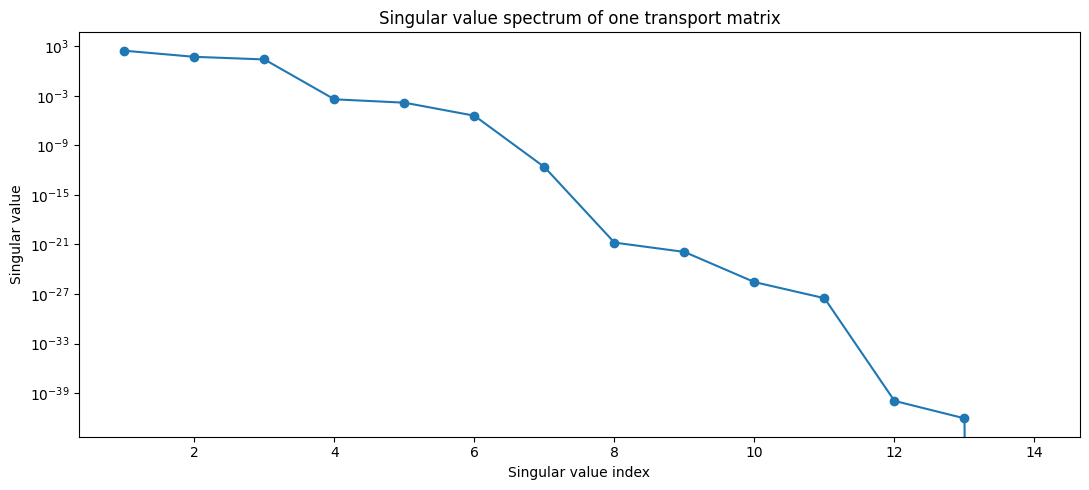

In [60]:
# Singular values for one representative transport matrix
t0 = snapshot_times[0]
snap = get_snapshot_frame(df_full, t0)
C_obs, WS, WD, SR, lats, lons = build_station_vectors(snap, STATION_NAMES, POLLUTANT)
C_obs = impute_nan_with_median(C_obs)
WS = impute_nan_with_median(WS)
WD = impute_nan_with_median(WD)
SR = impute_nan_with_median(SR)
lats = impute_nan_with_median(lats)
lons = impute_nan_with_median(lons)
is_daytime = 6 <= pd.Timestamp(t0).hour <= 18
stability = [stability_class(ws, sr, is_daytime) for ws, sr in zip(WS, SR)]
T = build_transport_matrix(lats, lons, WS, WD, stability)

svals = svd(T, compute_uv=False)
fig, ax = plt.subplots()
ax.plot(np.arange(1, len(svals) + 1), svals, marker="o")
ax.set_yscale("log")
ax.set_xlabel("Singular value index")
ax.set_ylabel("Singular value")
ax.set_title("Singular value spectrum of one transport matrix")
plt.tight_layout()
plt.show()


## 7) Inspect emission estimates

This is useful for seeing how sparse the inferred emissions are across methods.


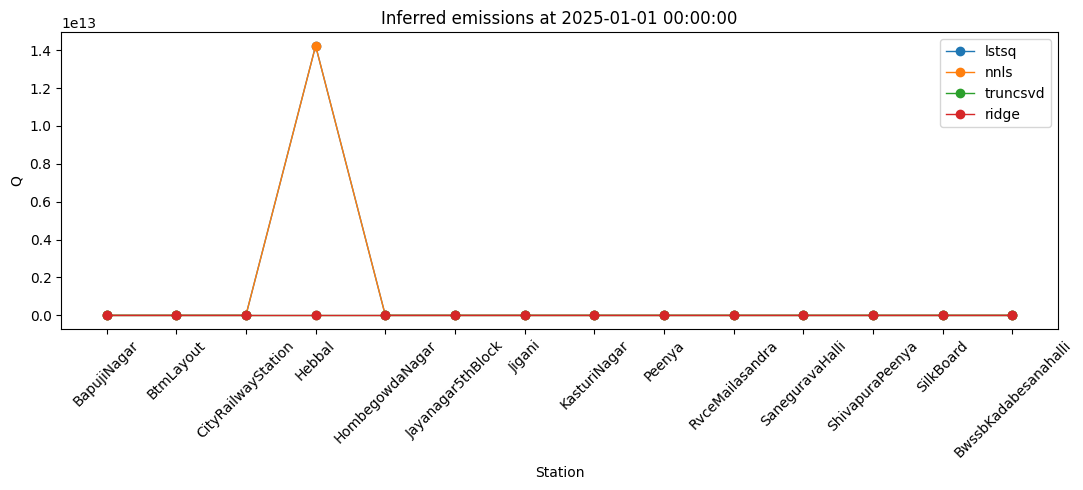

In [61]:
# Emission comparison for a chosen snapshot
t0 = snapshot_times[0]
fig, ax = plt.subplots()

for m in methods_order:
    Q = all_q[(t0, m)]
    ax.plot(STATION_NAMES, Q, marker="o", linewidth=1, label=m)

ax.set_title(f"Inferred emissions at {t0}")
ax.set_xlabel("Station")
ax.set_ylabel("Q")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()


## 8) Save results

This writes the per-snapshot results to CSV for later analysis.


In [ ]:
OUT_CSV = Path("transport_inversion_results.csv")
results_df.to_csv(OUT_CSV, index=False)
print(f"Saved: {OUT_CSV.resolve()}")
